## EGU 2026 Talk
Notebook to create figures used in my talk for EGU 2026.

In [30]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datatree import DataTree, open_datatree
import xskillscore
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

from isca_tools import plot
from isca_tools.plot import fig_resize, colored_line, update_linewidth, update_fontsize, savefig
from isca_tools.utils.fourier import coef_conversion
from isca_tools.utils.xarray import convert_ds_dtypes, update_dim_slice
from pathlib import Path
import os
import warnings
from glob import glob
from tqdm.notebook import tqdm

from isca_tools.utils.moist_physics import sphum_sat
import jobs.thesis_season.thesis_figs.utils as utils
from jobs.era5.surface_flux.av_annual_cycle.hysteresis_check_get_data import get_rh
from jobs.theory_lapse.cesm.thesis_figs.scripts.utils import initialize_ax_projection, plot_contour_projection

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

## Single Coordinate Plots
### Load all data at the single coordinate

In [3]:
data_dir = f'/Users/joshduffield/Documents/StAndrews/Isca/jobs/era5/surface_flux/av_annual_cycle/output_20years/'
ds = xr.open_mfdataset(f'{data_dir}/*.nc')
lat_single = 38
lon_single = 150
ds_single = ds.sel(latitude=lat_single, longitude=lon_single)
ds_single['net_up_flux'] = -ds_single.mslhf - ds_single.msshf - ds_single.msnlwrf
ds_single['w_atm'] = np.sqrt(ds_single['u10'] ** 2 + ds_single['v10'] ** 2)
ds_single['rh_atm'] = get_rh(ds_single.d2m, ds_single.t2m, ds_single.sp)
ds_single['t_dq'] = ds_single.skt - ds_single.t2m
ds_single = ds_single.drop_vars(['u10', 'v10', 'sp', 'd2m', 't2m'])
ds_single = ds_single.load()

# Expand out to new dimensions accounting for the different fitting metrics.
fit_method = xr.DataArray(['simulated', 'direct', 'linear', 'linear_phase'], name='fit_method',
                          dims='fit_method')
fit_method = fit_method.assign_coords(fit_method=fit_method.values)
ds_single = ds_single.expand_dims(fit_method=fit_method)

## Compute Fitting of all variables
Below I compute the annual harmonic and then empirical estimates of all the variables loaded in.

In [4]:
for key in ds_single:
    var = utils.get_fourier_fit_xr(np.arange(ds.time.size), ds_single[key].sel(fit_method='simulated'),
                                   n_harmonics=1, pad_coefs_phase=True)[0]
    ds_single[key] = update_dim_slice(ds_single[key].copy(deep=True), 'fit_method', 'direct', var)

In [5]:
fit_params = {}
for key in ds_single:
    for key2 in ['linear', 'linear_phase']:
        if key in ['skt', 'msnswrf']:
            ds_single[key] = update_dim_slice(ds_single[key].copy(deep=True), 'fit_method', key2, 0)
            continue
        # Compute params with simulated flux
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", np.RankWarning)
            var = utils.polyfit_phase_xr(ds_single.skt.sel(fit_method='simulated'),
                                         ds_single[key].sel(fit_method='simulated'), deg=1,
                                         include_phase='phase' in key2, include_fourier=False,
                                         deg_phase_calc=10)
        if key not in fit_params:
            fit_params[key] = var.expand_dims(fit_method=fit_method.where(fit_method.str.contains('linear'), drop=True))
        else:
            fit_params[key] = update_dim_slice(fit_params[key].copy(deep=True), 'fit_method', key2, var)
        # Fit with annual harmonic, as idea is to get a match to annual harmonic
        var = utils.polyval_phase_xr(fit_params[key].sel(fit_method=key2),
                                     ds_single.skt.sel(fit_method='direct'))
        ds_single[key] = update_dim_slice(ds_single[key].copy(deep=True), 'fit_method', key2, var)
fit_params = xr.Dataset(fit_params)

In [97]:
lw_use = 4
style_map = utils.style_map
style_map['simulated'] = ['C0', '-', 'ERA5', lw_use]
style_map['direct'] = ['k', '-', 'Annual harmonic', lw_use / 2]
style_map['linear'] = ['k', ':', 'Linear', lw_use / 2]
style_map['linear_phase'] = ['k', '--', 'Linear phase', lw_use / 2]
style_map['mslhf'] = ['$\\text{LH}^{\\uparrow}$']
style_map['msshf'] = ['$\\text{SW}^{\\uparrow}$']
style_map['msnlwrf'] = ['$\\text{LW}^{\\uparrow} - \\text{LW}^{\\downarrow}$']
style_map['rh_atm'] = ['$r_a$']

month_days = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
month_starts = np.concatenate(([0], np.cumsum(month_days)[:-1]))
month_ticks = (
    month_starts + month_days / 2,
    ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'],
)

Variance explained for msnswrf: 0.97
Variance explained for skt: 0.98


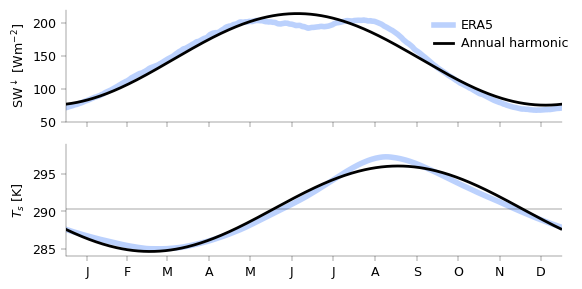

In [7]:
skip_direct = False
simulated_alpha = 0.4
fig, ax = plt.subplots(2, 1, sharex=True)
fig_resize(fig, utils.width['one_col'] * 2, 4)
for key in ['simulated', 'direct']:
    for i, key2 in enumerate(['msnswrf', 'skt']):
        time_plot = np.arange(ds.time.size)
        if skip_direct and key == 'direct':
            time_plot = time_plot - 1000
        ax[i].plot(time_plot, ds_single[key2].sel(fit_method=key), color=style_map[key][0], label=style_map[key][2],
                   lw=style_map[key][3], alpha=simulated_alpha if key == 'simulated' else 1)
        if key == 'simulated':
            var = float(
                xskillscore.r2(ds_single[key2].sel(fit_method='simulated'), ds_single[key2].sel(fit_method='direct'),
                               dim='time'))
            print(f"Variance explained for {key2}: {var:.2f}")
ax[1].axhline(ds_single.skt.sel(fit_method='direct').mean(), color='k', lw=ax_linewidth)
ax[0].set_xlim(0, ds.time.size)
ax[0].legend(loc='upper right', bbox_to_anchor=(1.03, 1))
ax[0].set_xticks(*month_ticks)
ax[0].set_ylabel('$\\text{SW}^{\\downarrow}$ [Wm$^{-2}$]')
ax[1].set_ylabel('$T_s$ [K]')
update_fontsize(fig, 4.5)
ax[0].set_ylim(50, 220)
lims_temp_surf = [284, 299]
ax[1].set_ylim(lims_temp_surf)
plt.show()
# savefig(fig)

Variance explained for net_up_flux: 0.99
Variance explained for skt: 0.98
lambda = -17.2 W/m2/K
lambda_phase = 26.6 W/m2/K
lambda_mod = -31.7 W/m2/K
time lag = -45.5 days


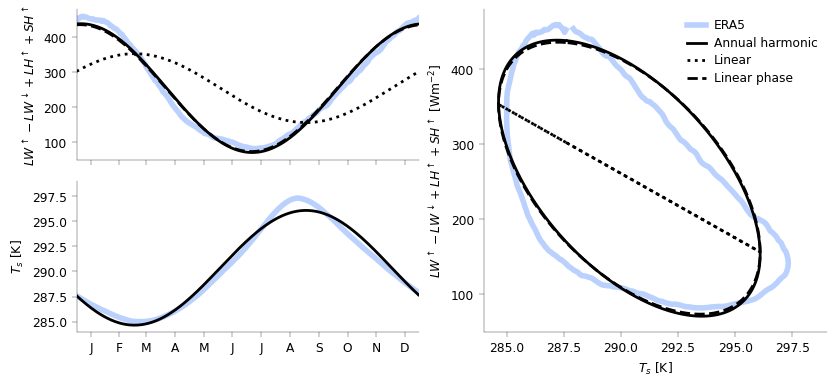

In [8]:
simulated_alpha = 0.4
skip_direct = False
skip_linear = False
show_linear_shift = False
fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(2, 2)

ax = [fig.add_subplot(gs[0, 0])]
ax.append(fig.add_subplot(gs[1, 0], sharex=ax[0]))
ax.append(fig.add_subplot(gs[:, 1], sharey=ax[0]))  # span both rows in second column

ax[0].label_outer()  # hides x tick labels on top-left
fig_resize(fig, utils.width['two_col'] * 1.5, 2.2)
for key in ['simulated', 'direct']:
    for i, key2 in enumerate(['net_up_flux', 'skt']):
        time_plot = np.arange(ds.time.size)
        if skip_direct and key == 'direct':
            time_plot = time_plot - 1000
        ax[i].plot(time_plot, ds_single[key2].sel(fit_method=key), color=style_map[key][0], label=style_map[key][2],
                   lw=style_map[key][3], alpha=simulated_alpha if key == 'simulated' else 1)
        if key == 'simulated':
            var = float(
                xskillscore.r2(ds_single[key2].sel(fit_method='simulated'), ds_single[key2].sel(fit_method='direct'),
                               dim='time'))
            print(f"Variance explained for {key2}: {var:.2f}")
    ax[2].plot(ds_single['skt'].sel(fit_method=key), ds_single['net_up_flux'].sel(fit_method=key),
               color=style_map[key][0],
               label=style_map[key][2], lw=style_map[key][3], alpha=simulated_alpha if key == 'simulated' else 1)

key = 'linear'
ax[0].plot(np.arange(ds.time.size) - skip_linear * 1000, ds_single['net_up_flux'].sel(fit_method=key),
           color=style_map[key][0], label=style_map[key][2],
           lw=style_map[key][3], linestyle=style_map[key][1])
ax[2].plot(ds_single['skt'].sel(fit_method='direct') - skip_linear * 1000, ds_single['net_up_flux'].sel(fit_method=key),
           color=style_map[key][0], label=style_map[key][2], lw=style_map[key][3], linestyle=style_map[key][1])

print(f"lambda = {fit_params['net_up_flux'].sel(fit_method='linear_phase', deg='1'):.1f} W/m2/K")
print(f"lambda_phase = {fit_params['net_up_flux'].sel(fit_method='linear_phase', deg='phase'):.1f} W/m2/K")
param_use = coef_conversion(cos_coef=fit_params['net_up_flux'].sel(fit_method='linear_phase', deg='1'),
                            sin_coef=fit_params['net_up_flux'].sel(fit_method='linear_phase', deg='phase'),
                            take_cos_sign=True)
print(f"lambda_mod = {param_use[0]:.1f} W/m2/K")
print(f"time lag = {np.arctan(param_use[1]) / (2 * np.pi / ds.time.size):.1f} days")

key = 'linear_phase'
lambda_ratio = fit_params['net_up_flux'].sel(fit_method='linear_phase', deg='1') / param_use[0]
flux_fit_linear_shift = (lambda_ratio * (
            ds_single['net_up_flux'].sel(fit_method=key) - ds_single['net_up_flux'].sel(fit_method=key).mean()) +
                         ds_single['net_up_flux'].sel(fit_method=key).mean())

ax[0].plot(np.arange(ds.time.size) - skip_linear * 1000,
           flux_fit_linear_shift if show_linear_shift else ds_single['net_up_flux'].sel(fit_method=key),
           color=style_map[key][0], label=style_map[key][2], lw=style_map[key][3], linestyle=style_map[key][1])
ax[2].plot(ds_single['skt'].sel(fit_method='direct') - skip_linear * 1000,
           flux_fit_linear_shift if show_linear_shift else ds_single['net_up_flux'].sel(fit_method=key),
           color=style_map[key][0], label=style_map[key][2], lw=style_map[key][3], linestyle=style_map[key][1])

ax[0].set_xlim(0, ds.time.size)
lims_up_flux = [50, 480]
ax[0].set_ylim(lims_up_flux)
ax[0].set_xticks(*month_ticks)
ax[2].set_xticks(ax[1].get_yticks())
ax[1].set_ylim(lims_temp_surf)
ax[2].set_xlim(lims_temp_surf)
ax[2].legend(loc='upper right')
ax[0].set_ylabel('$LW^{\\uparrow}-LW^{\\downarrow} + LH^{\\uparrow} + SH^{\\uparrow}$')
ax[2].set_ylabel('$LW^{\\uparrow}-LW^{\\downarrow} + LH^{\\uparrow} + SH^{\\uparrow}$ [Wm$^{-2}$]')
ax[1].set_ylabel('$T_s$ [K]')
ax[2].set_xlabel('$T_s$ [K]')
update_fontsize(fig, 7.5)
# ax[0].set_ylabel('Net upward flux [Wm$^{-2}$]')

plt.show()
# savefig(fig)

## Flux decomposition
Below I show which flux has the largest contribution to the error, and thus for which the time delay is most crucial.

mslhf
Error (mean absolute) = 59.3 W/m2
Error (normalised) = 57.9%
lambda = -7.3 W/m2/K
lambda_phase = 16.1 W/m2/K
lambda_mod = -17.7 W/m2/K
time lag = -49.5 days
msshf
Error (mean absolute) = 26.4 W/m2
Error (normalised) = 45.7%
lambda = -6.7 W/m2/K
lambda_phase = 7.2 W/m2/K
lambda_mod = -9.8 W/m2/K
time lag = -40.1 days
msnlwrf
Error (mean absolute) = 12.0 W/m2
Error (normalised) = 44.9%
lambda = -3.2 W/m2/K
lambda_phase = 3.3 W/m2/K
lambda_mod = -4.6 W/m2/K
time lag = -39.1 days


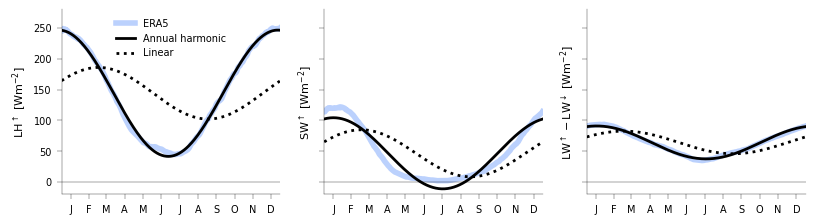

In [95]:
flux_plot = ['mslhf', 'msshf', 'msnlwrf']
# flux_plot = 'msnlwrf'
simulated_alpha = 0.4
fig, ax = plt.subplots(1, len(flux_plot), sharex=True, sharey=True)
fig_resize(fig, utils.width['one_col']*3)
for i, key2 in enumerate(flux_plot):
    for key in ['simulated', 'direct', 'linear']:
        time_plot = np.arange(ds.time.size)
        if skip_direct and key == 'direct':
            time_plot = time_plot - 1000
        ax[i].plot(time_plot, -ds_single[key2].sel(fit_method=key), color=style_map[key][0], label=style_map[key][2],
                lw=style_map[key][3], alpha=simulated_alpha if key == 'simulated' else 1,
                linestyle=style_map[key][1])
    ax[i].axhline(0, color='k', lw=ax_linewidth)
    ax[i].set_ylabel(style_map[key2][0] + " [Wm$^{-2}$]")

    print(key2)
    error_flux = np.abs(ds_single[key2].sel(fit_method='direct') - ds_single[key2].sel(fit_method='linear')).mean(dim='time')
    print(f"Error (mean absolute) = {error_flux:.1f} W/m2")
    error_norm_factor_flux = 0.5 * (
                ds_single[key2].sel(fit_method='direct').max(dim='time') - ds_single[key2].sel(fit_method='direct').min(dim='time'))
    print(f"Error (normalised) = {error_flux/error_norm_factor_flux*100:.1f}%")

    print(f"lambda = {-fit_params[key2].sel(fit_method='linear_phase', deg='1'):.1f} W/m2/K")
    print(f"lambda_phase = {-fit_params[key2].sel(fit_method='linear_phase', deg='phase'):.1f} W/m2/K")
    param_use = coef_conversion(cos_coef=-fit_params[key2].sel(fit_method='linear_phase', deg='1'),
                                sin_coef=-fit_params[key2].sel(fit_method='linear_phase', deg='phase'),
                                take_cos_sign=True)
    print(f"lambda_mod = {param_use[0]:.1f} W/m2/K")
    print(f"time lag = {np.arctan(param_use[1]) / (2 * np.pi / ds.time.size):.1f} days")
ax[0].set_xticks(*month_ticks)
ax[0].set_ylim(-20, 280)
ax[0].set_xlim(0, ds.time.size)
ax[0].legend()
plt.show()
# savefig(fig)

## Latent heat decomposition
Above we see that latent heat is the dominant cause of the error. So we look at relative humidity which has similar time delay.

rh_atm
Error (mean absolute) = 0.0 W/m2
Error (normalised) = 49.7%
lambda = 0.0 W/m2/K
lambda_phase = -0.0 W/m2/K
lambda_mod = 0.0 W/m2/K
time lag = -42.2 days


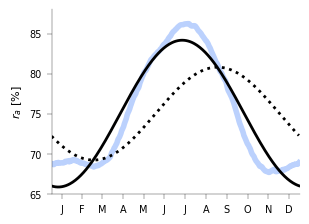

In [108]:
flux_plot = ['rh_atm']
# flux_plot = 'msnlwrf'
simulated_alpha = 0.4
fig, ax = plt.subplots(1, len(flux_plot), sharex=True, sharey=True)
ax = [ax]
fig_resize(fig, utils.width['one_col'])
for i, key2 in enumerate(flux_plot):
    for key in ['simulated', 'direct', 'linear']:
        time_plot = np.arange(ds.time.size)
        if skip_direct and key == 'direct':
            time_plot = time_plot - 1000
        ax[i].plot(time_plot, 100*ds_single[key2].sel(fit_method=key), color=style_map[key][0], label=style_map[key][2],
                lw=style_map[key][3], alpha=simulated_alpha if key == 'simulated' else 1,
                linestyle=style_map[key][1])
    ax[i].set_ylabel(style_map[key2][0] + " [%]")

    print(key2)
    error_flux = np.abs(ds_single[key2].sel(fit_method='direct') - ds_single[key2].sel(fit_method='linear')).mean(dim='time')
    print(f"Error (mean absolute) = {error_flux:.1f} W/m2")
    error_norm_factor_flux = 0.5 * (
                ds_single[key2].sel(fit_method='direct').max(dim='time') - ds_single[key2].sel(fit_method='direct').min(dim='time'))
    print(f"Error (normalised) = {error_flux/error_norm_factor_flux*100:.1f}%")

    print(f"lambda = {fit_params[key2].sel(fit_method='linear_phase', deg='1'):.1f} W/m2/K")
    print(f"lambda_phase = {fit_params[key2].sel(fit_method='linear_phase', deg='phase'):.1f} W/m2/K")
    param_use = coef_conversion(cos_coef=fit_params[key2].sel(fit_method='linear_phase', deg='1'),
                                sin_coef=fit_params[key2].sel(fit_method='linear_phase', deg='phase'),
                                take_cos_sign=True)
    print(f"lambda_mod = {param_use[0]:.1f} W/m2/K")
    print(f"time lag = {np.arctan(param_use[1]) / (2 * np.pi / ds.time.size):.1f} days")
ax[0].set_xticks(*month_ticks)
ax[0].set_xlim(0, ds.time.size)
ax[0].set_ylim(65, 88)
plt.show()
# savefig(fig)

## Global data
The only global plot I make is of the error in the linear approximation.

I mask in white all coordinates where less than 80% of variance in mean cycle of surface temperature is explained by annual harmonic.

In [9]:
small_grid = False
small_lat = slice(40, 0)
small_lon = slice(90, 150)
load_indiv_flux = False
files_fourier = sorted(glob(os.path.join(data_dir, "fourier_coef", "*.nc")))
var_all = {}
var_all['net_up_flux'] = {'simulated': (-ds.mslhf - ds.msshf - ds.msnlwrf)}
var_all['skt'] = {'simulated': ds.skt}
if small_grid:
    for i, key in enumerate(var_all):
        var_all[key]['simulated'] = var[key]['simulated'].sel(latitude=small_lat, longitude=small_lon)
for i, key in tqdm(enumerate(var_all), total=len(var_all)):
    var_all[key]['simulated'] = var_all[key]['simulated'].load()

  0%|          | 0/2 [00:00<?, ?it/s]

In [10]:
# Load in fourier coefficients
fourier_coef = {}
for key in ['amp', 'phase']:
    fourier_coef[key] = xr.merge([
        xr.open_dataset(f)[[key]].rename({key: Path(f).stem})
        for f in files_fourier
    ])
    if small_grid:
        fourier_coef[key] = fourier_coef[key].sel(latitude=small_lat, longitude=small_lon)
    fourier_coef[key].load()

In [12]:
# Compute annual harmonic
for i, key in tqdm(enumerate(var_all), total=len(var_all)):
    var_all[key]['direct'] = utils.fourier_series_xr(np.arange(ds.time.size), fourier_coef['amp'][key],
                                                     fourier_coef['phase'][key], pad_coefs_phase=True).astype('float32')

  0%|          | 0/2 [00:00<?, ?it/s]

In [13]:
fit_params_all = xr.open_mfdataset(f'{data_dir}/empirical_fitting/*.nc')
if small_grid:
    fit_params_all = fit_params_all.sel(latitude=small_lat, longitude=small_lon)
fit_params_all = fit_params_all.load()

In [14]:
var_to_fit = ['net_up_flux']
with tqdm(total=len(var_to_fit)) as pbar:
    for key in var_to_fit:
        for key2 in ['linear']:
            # Use actual skt for variable e.g. wind and rh but annual harmonic for the fluxes
            var_all[key][key2] = utils.polyval_phase_xr(fit_params_all[key].sel(fit_method=key2),
                                                        var_all['skt']['direct']).astype('float32')
            pbar.update(1)

  0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 2.76 s, sys: 4.64 s, total: 7.4 s
Wall time: 13.9 s


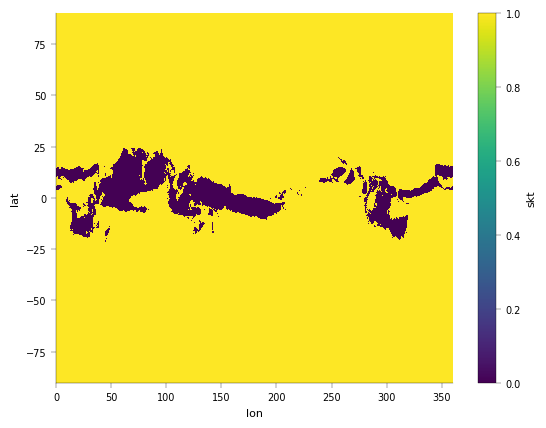

In [15]:
%%time
thresh_var_explained = 0.8
mask = xskillscore.r2(var_all['skt']['simulated'], var_all['skt']['direct'], dim='time') > 0.8
mask = mask.rename({'latitude': 'lat', 'longitude': 'lon'})
mask.plot()

In [16]:
%%time
norm_error = True
error = np.abs(var_all['net_up_flux']['direct'] - var_all['net_up_flux']['linear']).mean(dim='time')
print(f"Error (mean absolute) = {error.sel(latitude=lat_single, longitude=lon_single):.1f} W/m2")
error_norm_factor = 0.5 * (
            var_all['net_up_flux']['direct'].max(dim='time') - var_all['net_up_flux']['direct'].min(dim='time'))
if norm_error:
    error = error / error_norm_factor * 100
print(f"Norm factor (amplitude) = {error_norm_factor.sel(latitude=lat_single, longitude=lon_single):.1f} W/m2")
print(f"Error (normalised) = {error.sel(latitude=lat_single, longitude=lon_single):.1f}%")
error = error.rename({'latitude': 'lat', 'longitude': 'lon'})

Error (mean absolute) = 97.7 W/m2
Norm factor (amplitude) = 184.2 W/m2
Error (normalised) = 53.0%
CPU times: user 3.75 s, sys: 3.91 s, total: 7.65 s
Wall time: 15.7 s


In [ ]:
def plot_scatter_mask(lon_plot=lon_single, lat_plot=lat_single, ax, s=12, color='k', marker='.', zorder=20,
                      edgecolors='None', linewidths=1.0):
    # Cyclic versions of BOTH data and mask along lon axis=1
    mask_c, lon_c = add_cyclic_point(mask.values.astype(int), coord=mask["lon"].values, axis=1)  # [web:66]
    mask_c = mask_c.astype(bool)

    # Scatter where True (now indices match lon_c)
    iy, ix = np.where(mask_c)

    lon_pts = lon_c[ix]
    lat_pts = mask["lat"].values[iy]

    return ax.scatter(lon_pts, lat_pts, transform=ccrs.PlateCarree(),
                      s=s, marker=marker, facecolors=color, edgecolors=edgecolors, zorder=zorder, linewidths=linewidths)

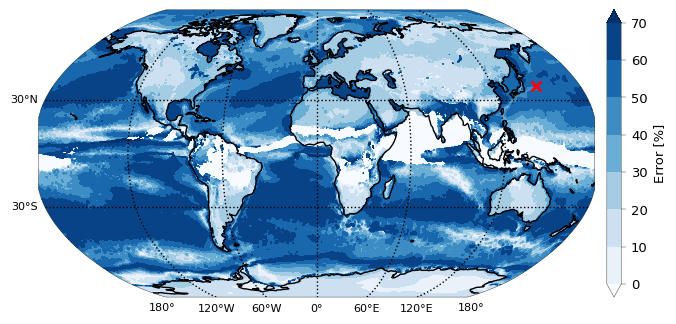

CPU times: user 41.7 s, sys: 564 ms, total: 42.2 s
Wall time: 40.4 s


In [41]:
%%time
gl_fontsize = 8
fig = plt.figure(constrained_layout=True)
ax = fig.subplots(1, 1, subplot_kw={'projection': ccrs.Robinson()}, gridspec_kw={'hspace': 0})
fig_resize(fig, 25, ar=8)
gl = initialize_ax_projection(ax, lat_min=-90, lat_max=90, grid_lat=[-30, 30], return_gl=True, coastline_lw=1,
                              gridline_lw=1)[1]
gl.xlabel_style = {"size": gl_fontsize, "color": 'k'}
gl.ylabel_style = {"size": gl_fontsize}
contour_lev = np.arange(0, 80, 10)
im = plot_contour_projection(ax, error, levels=contour_lev, cmap='Blues', mask=mask)
plt.colorbar(im, ax=ax, label='Error [%]', pad=0.005)
ax.scatter(lon_single, lat_single, transform=ccrs.PlateCarree(), marker='x', zorder=20, color='r', s=50, linewidths=2)
update_fontsize(fig, 5)
plt.show()
# savefig(fig)